# Open-Shell Molecules: Method Comparison vs CCSDT(Q) — VTZ(f,p) Basis

Compare **UHF-UCCSD(T)**, **UHF-UCCSDT**, and **AFQMC** total energies against the
**CCSDT(Q)** reference for all 40 open-shell molecules in the W4-17 dataset.

Energy deviations are reported as $\Delta E = E_\mathrm{method} - E_\mathrm{CCSDT(Q)}$ in mE$_h$.
RMSD is root-mean-square deviation over all molecules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.dpi': 120,
})

DATA_DIR = Path('.')

In [2]:
def safe_float(s):
    try:
        return float(s)
    except (ValueError, TypeError):
        return None


def parse_reference(path):
    """Parse reference_vtzfp.dat.
    Columns: Molecule, E_HF, E_CCSD, E_UHF-UCCSD(T), E_UHF-UCCSDT, E_CCSDT(Q)
    """
    data = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#') or line.startswith('-') or line.startswith('Molecule'):
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            mol = parts[0]
            data[mol] = {
                'E_HF':     safe_float(parts[1]),
                'E_CCSD':   safe_float(parts[2]),
                'E_CCSDT':  safe_float(parts[3]),   # UHF-UCCSD(T)
                'E_CCSDT3': safe_float(parts[4]) if len(parts) > 4 else None,  # UHF-UCCSDT
                'E_CCSDTQ': safe_float(parts[5]) if len(parts) > 5 else None,  # CCSDT(Q)
            }
    return data


def parse_afqmc(path):
    """Parse open_vtzfp.dat.
    Columns: Molecule, Shell, E_HF, E_CCSD, E_AFQMC, E_AFQMC_ERR, nelec, norb, Runtime
    """
    data = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('-') or line.startswith('Molecule'):
                continue
            parts = line.split()
            if len(parts) < 6:
                continue
            mol = parts[0]
            data[mol] = {
                'E_HF':       safe_float(parts[2]),
                'E_CCSD':     safe_float(parts[3]),
                'E_AFQMC':    safe_float(parts[4]),
                'E_AFQMC_err': safe_float(parts[5]),
            }
    return data


ref  = parse_reference(DATA_DIR / 'reference_vtzfp.dat')
afqmc = parse_afqmc(DATA_DIR / 'open_vtzfp.dat')

print(f'Reference molecules loaded : {len(ref)}')
print(f'AFQMC molecules loaded     : {len(afqmc)}')

Reference molecules loaded : 211
AFQMC molecules loaded     : 40


In [3]:
# Build comparison table for open-shell molecules
rows = []
for mol in sorted(afqmc.keys()):
    if mol not in ref:
        print(f'WARNING: {mol} not found in reference data')
        continue
    r = ref[mol]
    a = afqmc[mol]
    q = r['E_CCSDTQ']
    if q is None:
        print(f'WARNING: {mol} has no CCSDT(Q) reference')
        continue

    dE_ccsdt  = (r['E_CCSDT']  - q) * 1e3 if r['E_CCSDT']  is not None else None
    dE_ccsdt3 = (r['E_CCSDT3'] - q) * 1e3 if r['E_CCSDT3'] is not None else None
    dE_afqmc  = (a['E_AFQMC']  - q) * 1e3 if a['E_AFQMC']  is not None else None

    rows.append({
        'mol':           mol,
        'E_CCSDTQ':      q,
        'dE_CCSDT':      dE_ccsdt,
        'dE_CCSDT3':     dE_ccsdt3,
        'dE_AFQMC':      dE_afqmc,
        'dE_AFQMC_err':  a['E_AFQMC_err'] * 1e3 if a['E_AFQMC_err'] is not None else None,
    })

mols      = [r['mol']          for r in rows]
dE_ccsdt  = np.array([r['dE_CCSDT']  for r in rows], dtype=float)
dE_ccsdt3 = np.array([r['dE_CCSDT3'] for r in rows], dtype=float)
dE_afqmc  = np.array([r['dE_AFQMC']  for r in rows], dtype=float)
err_afqmc = np.array([r['dE_AFQMC_err'] for r in rows], dtype=float)

print(f'Molecules in comparison: {len(rows)}')
print(f"{'Molecule':<16} {'ΔCCSD(T)':>10} {'ΔCCSDT':>10} {'ΔAFQMC':>12} {'±σ':>8}")
print('-' * 62)
for r in rows:
    ccsdt_s  = f"{r['dE_CCSDT']:>10.4f}"  if r['dE_CCSDT']  is not None else f"{'missing':>10}"
    ccsdt3_s = f"{r['dE_CCSDT3']:>10.4f}" if r['dE_CCSDT3'] is not None else f"{'missing':>10}"
    afqmc_s  = f"{r['dE_AFQMC']:>12.4f}"  if r['dE_AFQMC']  is not None else f"{'missing':>12}"
    err_s    = f"{r['dE_AFQMC_err']:>8.4f}" if r['dE_AFQMC_err'] is not None else f"{'':>8}"
    print(f"{r['mol']:<16} {ccsdt_s} {ccsdt3_s} {afqmc_s} {err_s}")

Molecules in comparison: 40
Molecule           ΔCCSD(T)     ΔCCSDT       ΔAFQMC       ±σ
--------------------------------------------------------------
allyl                2.5040     1.1050       0.3880   0.1380
b2                   3.2640     1.8530       2.6090   0.1870
bn3pi                2.7240     1.1650       2.3110   0.2330
c-hooo               4.6230     3.6710       1.3950   0.4040
cch                  2.7060     1.2100       1.7870   0.2180
cf                   1.1250     0.5420       0.9160   0.1660
ch                   0.7190     0.0750       0.2440   0.0430
ch2-trip             0.5600     0.0690       0.0570   0.0250
ch2ch                1.9610     0.7250       0.7570   0.1040
ch2nh2               1.0720     0.5670       0.3840   0.1280
ch3                  0.5810     0.1050       0.0100   0.0370
ch3nh                1.1540     0.4620       0.1980   0.1050
clo                  2.3140     1.1990       0.8520   0.1680
clo3                 3.9030     4.1100       2.7020   0

In [4]:
# RMSD calculation
def rmsd(arr):
    valid = arr[np.isfinite(arr)]
    return np.sqrt(np.mean(valid**2)), len(valid)

rmsd_ccsdt,  n1 = rmsd(dE_ccsdt)
rmsd_ccsdt3, n2 = rmsd(dE_ccsdt3)
rmsd_afqmc,  n3 = rmsd(dE_afqmc)
# AFQMC statistical uncertainty on the RMSD (propagated from error bars)
afqmc_sigma = np.sqrt(np.mean(err_afqmc[np.isfinite(err_afqmc)]**2))

print('RMSD from CCSDT(Q) [mEh] — open-shell W4-17, VTZ(f,p) basis')
print('=' * 55)
print(f"{'Method':<20} {'RMSD (mEh)':>12} {'σ_stat':>10} {'N':>5}")
print('-' * 55)
print(f"{'UHF-UCCSD(T)':<20} {rmsd_ccsdt:>12.4f} {'':>10} {n1:>5}")
print(f"{'UHF-UCCSDT':<20} {rmsd_ccsdt3:>12.4f} {'':>10} {n2:>5}")
print(f"{'AFQMC':<20} {rmsd_afqmc:>12.4f} {afqmc_sigma:>10.4f} {n3:>5}")

RMSD from CCSDT(Q) [mEh] — open-shell W4-17, VTZ(f,p) basis
Method                 RMSD (mEh)     σ_stat     N
-------------------------------------------------------
UHF-UCCSD(T)               2.8185               40
UHF-UCCSDT                 2.0882               40
AFQMC                      1.7513     0.2302    40


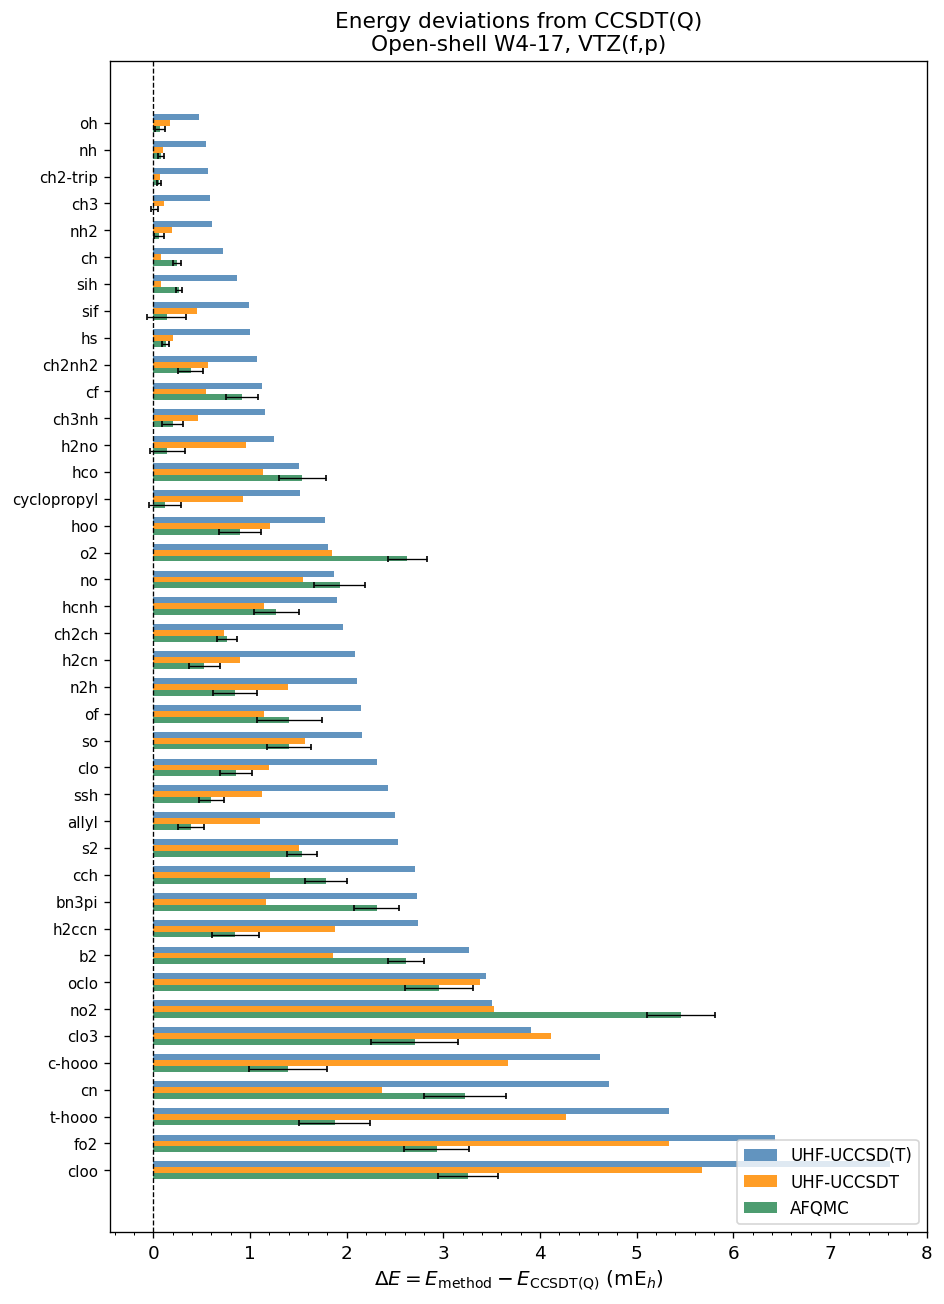

In [5]:
# ── Plot 1: Per-molecule deviations ─────────────────────────────────────────
# Sort molecules by CCSDT(Q) total energy (ascending = smallest/lightest first)
order = np.argsort(dE_ccsdt)[::-1]  # sort by CCSD(T) deviation, largest first
mols_ord      = [mols[i]       for i in order]
dE_ccsdt_ord  = dE_ccsdt[order]
dE_ccsdt3_ord = dE_ccsdt3[order]
dE_afqmc_ord  = dE_afqmc[order]
err_afqmc_ord = err_afqmc[order]

y = np.arange(len(mols_ord))
fig, ax = plt.subplots(figsize=(8, 11))

ax.barh(y + 0.22, dE_ccsdt_ord,  height=0.22, color='steelblue',  label='UHF-UCCSD(T)', alpha=0.85)
ax.barh(y + 0.00, dE_ccsdt3_ord, height=0.22, color='darkorange', label='UHF-UCCSDT',  alpha=0.85)
ax.barh(y - 0.22, dE_afqmc_ord,  height=0.22, color='seagreen',   label='AFQMC',       alpha=0.85,
        xerr=err_afqmc_ord, error_kw=dict(elinewidth=0.8, capsize=2, ecolor='black'))

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(mols_ord, fontsize=9)
ax.set_xlabel(r'$\Delta E = E_\mathrm{method} - E_\mathrm{CCSDT(Q)}$ (mE$_h$)')
ax.set_title('Energy deviations from CCSDT(Q)\nOpen-shell W4-17, VTZ(f,p)')
ax.legend(loc='lower right', fontsize=10)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
fig.tight_layout()
plt.savefig('deviations_open_vtzfp.png', dpi=150, bbox_inches='tight')
plt.show()

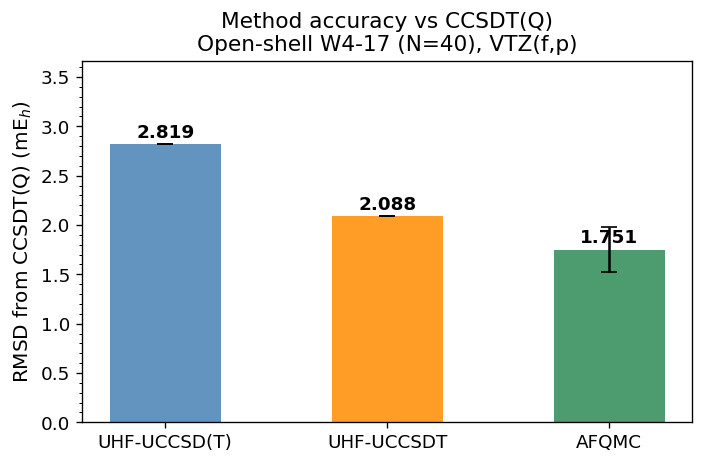


Final RMSD summary (mEh):
  UHF-UCCSD(T) : 2.8185
  UHF-UCCSDT   : 2.0882
  AFQMC        : 1.7513  (mean stat. err. = 0.2302 mEh)


In [6]:
# ── Plot 2: RMSD summary bar chart ──────────────────────────────────────────
methods = ['UHF-UCCSD(T)', 'UHF-UCCSDT', 'AFQMC']
rmsds   = [rmsd_ccsdt, rmsd_ccsdt3, rmsd_afqmc]
colors  = ['steelblue', 'darkorange', 'seagreen']
# AFQMC uncertainty bar represents the mean statistical error, not RMSD uncertainty
afqmc_err_bar = [0, 0, afqmc_sigma]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(methods, rmsds, color=colors, alpha=0.85, width=0.5,
              yerr=afqmc_err_bar, capsize=5,
              error_kw=dict(elinewidth=1.5, ecolor='black'))

for bar, val in zip(bars, rmsds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('RMSD from CCSDT(Q) (mE$_h$)')
ax.set_title(f'Method accuracy vs CCSDT(Q)\nOpen-shell W4-17 (N={n3}), VTZ(f,p)')
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.set_ylim(0, max(rmsds) * 1.3)
fig.tight_layout()
plt.savefig('rmsd_open_vtzfp.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFinal RMSD summary (mEh):')
print(f'  UHF-UCCSD(T) : {rmsd_ccsdt:.4f}')
print(f'  UHF-UCCSDT   : {rmsd_ccsdt3:.4f}')
print(f'  AFQMC        : {rmsd_afqmc:.4f}  (mean stat. err. = {afqmc_sigma:.4f} mEh)')

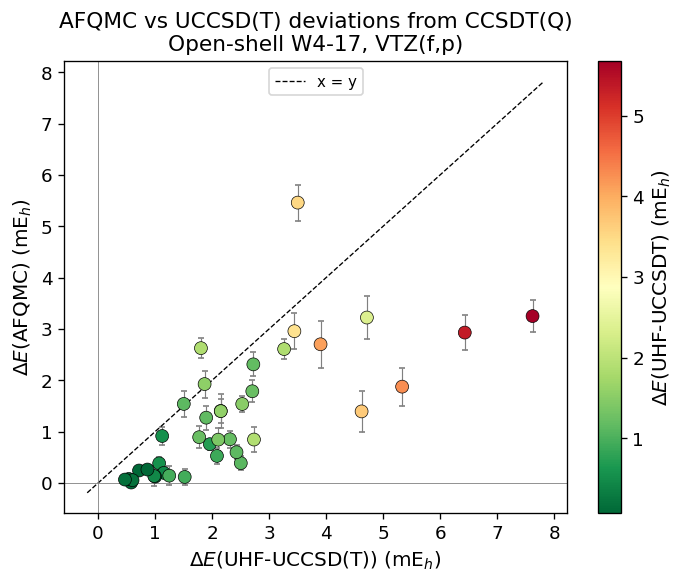

In [7]:
# ── Plot 3: Scatter — AFQMC vs CCSD(T) deviation ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(dE_ccsdt, dE_afqmc, c=dE_ccsdt3, cmap='RdYlGn_r',
                s=60, zorder=3, edgecolors='k', linewidths=0.4)
ax.errorbar(dE_ccsdt, dE_afqmc, yerr=err_afqmc,
            fmt='none', ecolor='gray', elinewidth=0.7, capsize=2, zorder=2)

lims = [min(dE_ccsdt.min(), dE_afqmc.min()) - 0.2,
        max(dE_ccsdt.max(), dE_afqmc.max()) + 0.2]
ax.plot(lims, lims, 'k--', linewidth=0.8, label='x = y')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

cbar = fig.colorbar(sc, ax=ax, label=r'$\Delta E$(UHF-UCCSDT) (mE$_h$)')
ax.set_xlabel(r'$\Delta E$(UHF-UCCSD(T)) (mE$_h$)')
ax.set_ylabel(r'$\Delta E$(AFQMC) (mE$_h$)')
ax.set_title('AFQMC vs UCCSD(T) deviations from CCSDT(Q)\nOpen-shell W4-17, VTZ(f,p)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig('scatter_open_vtzfp.png', dpi=150, bbox_inches='tight')
plt.show()